# Regularization and Optimization

            ## 1. Learning objectives

            - Implement inverted dropout
- Use batch normalization and weight decay
- Compare regularized validation curves

            ## 2. Prerequisites

            NumPy arrays, matrix multiplication, basic derivatives, and the supervised-learning workflow.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(1)
device = torch.device("cpu")
print("PyTorch:", torch.__version__, "| device:", device)

Python lesson ready; reproducible seed = 42
PyTorch: 2.14.0+cpu | device: cpu


## 3. Problem definition

            Optimize efficiently while limiting the gap between training fit and unseen-data performance.

            ## 4. Real-world use cases

            - Image recognition
- Sequence modeling
- Learned feature representations

            ## 5. Core intuition in simple language

            Regularization limits reliance on fragile details; optimizers decide how gradient information changes parameters.

## 6. Mathematical foundation

            $$\tilde{h}_j=\frac{m_jh_j}{1-p},\qquad m_j\sim Bernoulli(1-p).$$

            **Every symbol:**

            - $h_j$ is activation j.
- $m_j$ is a random keep mask.
- $p$ is dropout probability.
- $\tilde h_j$ is training-time output.

            **Why the equation is needed:** Division by keep probability preserves expected activation magnitude during training.

            **Small numerical example:** With h=2, p=.5, kept output is 2/(.5)=4 and dropped output is 0; expectation is 2.

            **Connection to Python:** nn.Dropout applies inverted dropout in train mode and becomes identity in eval mode.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Create tensors with explicit batch and feature dimensions
2. Run a forward pass
3. Compute a loss against targets
4. Backpropagate gradients
5. Update parameters with an optimizer
6. Evaluate on untouched validation data

## 9. Implementation from scratch

NumPy exposes the forward calculation and, where appropriate, the gradients.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def dropout_scratch(values, probability, seed=42):
    generator=np.random.default_rng(seed)
    mask=generator.random(values.shape)>=probability
    return values*mask/(1-probability),mask

values=np.ones(10)
dropped,mask=dropout_scratch(values,.5)
print("Mask:",mask.astype(int),"training mean:",round(dropped.mean(),2),"evaluation output:",values.mean())

Mask: [1 0 1 1 0 1 1 1 0 0] training mean: 1.2 evaluation output: 1.0


## 10. Implementation using a standard library

PyTorch tensors, modules, autograd, losses, and optimizers provide the standard implementation.

## 11. Dataset loading and exploration

Every lesson uses a generated sequence or a small dataset bundled with scikit-learn; no download is required.

## 12. Data preprocessing

Splits occur before fitted transformations. Inputs are converted to float32 tensors and class labels to int64.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Regularized model diagnostics: {'input_shape': (1257, 64), 'intermediate_shape': (1257, 64), 'output_shape': (1257, 10), 'trainable_parameters': 4938, 'final_training_loss': 0.601, 'final_validation_loss': 0.4669, 'validation_accuracy': 0.919}
Plain model final train/validation loss and accuracy: 0.5068 0.4342 0.902


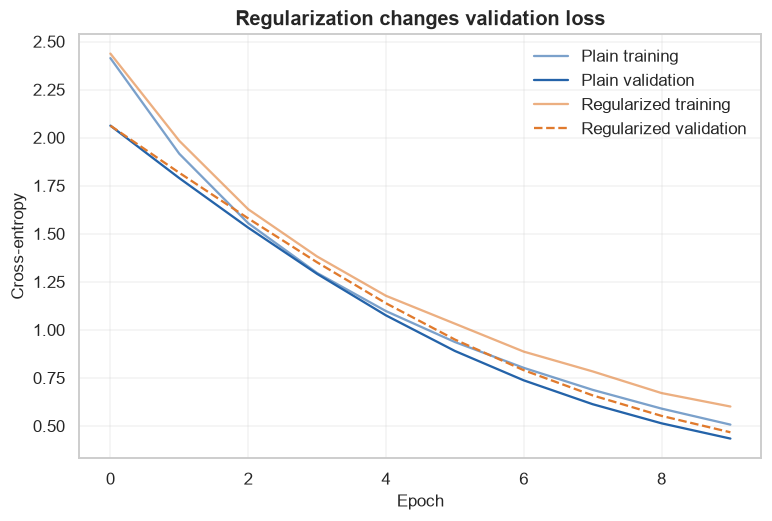

In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits=load_digits()
X_train,X_validation,y_train,y_validation=train_test_split(digits.data,digits.target,test_size=.3,stratify=digits.target,random_state=RANDOM_SEED)
scaler=StandardScaler(); X_train=scaler.fit_transform(X_train); X_validation=scaler.transform(X_validation)
train_X=torch.tensor(X_train,dtype=torch.float32); train_y=torch.tensor(y_train,dtype=torch.long)
validation_X=torch.tensor(X_validation,dtype=torch.float32); validation_y=torch.tensor(y_validation,dtype=torch.long)

def train_candidate(dropout,weight_decay):
    model=nn.Sequential(nn.Linear(64,64),nn.BatchNorm1d(64),nn.ReLU(),nn.Dropout(dropout),nn.Linear(64,10))
    optimizer=torch.optim.Adam(model.parameters(),lr=.01,weight_decay=weight_decay); loss_fn=nn.CrossEntropyLoss()
    train_history=[]; validation_history=[]
    for _ in range(10):
        model.train(); optimizer.zero_grad(); logits=model(train_X); loss=loss_fn(logits,train_y); loss.backward(); optimizer.step()
        model.eval()
        with torch.no_grad(): val_logits=model(validation_X); val_loss=loss_fn(val_logits,validation_y)
        train_history.append(loss.item()); validation_history.append(val_loss.item())
    accuracy=(val_logits.argmax(1)==validation_y).float().mean().item()
    return model,train_history,validation_history,accuracy

plain,plain_train,plain_val,plain_acc=train_candidate(0.0,0.0)
regularized,reg_train,reg_val,reg_acc=train_candidate(.3,1e-4)
regularized.eval()
with torch.no_grad():
    intermediate = regularized[2](regularized[1](regularized[0](train_X)))
print("Regularized model diagnostics:", {
    "input_shape": tuple(train_X.shape),
    "intermediate_shape": tuple(intermediate.shape),
    "output_shape": (len(train_X), 10),
    "trainable_parameters": sum(p.numel() for p in regularized.parameters()),
    "final_training_loss": round(reg_train[-1], 4),
    "final_validation_loss": round(reg_val[-1], 4),
    "validation_accuracy": round(reg_acc, 3),
})
print("Plain model final train/validation loss and accuracy:",round(plain_train[-1],4),round(plain_val[-1],4),round(plain_acc,3))
figure,axis=plt.subplots()
axis.plot(plain_train,label="Plain training",color=COURSE_COLORS["blue"],alpha=.6)
axis.plot(plain_val,label="Plain validation",color=COURSE_COLORS["blue"])
axis.plot(reg_train,label="Regularized training",color=COURSE_COLORS["orange"],alpha=.6)
axis.plot(reg_val,label="Regularized validation",color=COURSE_COLORS["orange"],linestyle="--")
axis.set(title="Regularization changes validation loss",xlabel="Epoch",ylabel="Cross-entropy"); axis.legend(); plt.show()

**How to interpret the result:** The comparison shows the generalization effect on one fixed split; repeated seeds are needed before a strong conclusion.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Higher dropout reduces active capacity; select it with validation results and use model.eval() during evaluation.

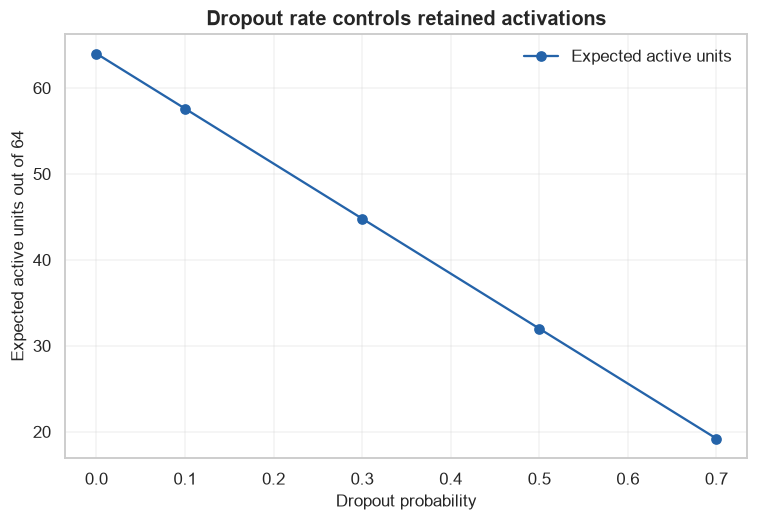

In [4]:
rates=[0,.1,.3,.5,.7]
expected_active=[64*(1-rate) for rate in rates]
figure,axis=plt.subplots()
axis.plot(rates,expected_active,marker="o",color=COURSE_COLORS["blue"],label="Expected active units")
axis.set(title="Dropout rate controls retained activations",xlabel="Dropout probability",ylabel="Expected active units out of 64")
axis.legend(); plt.show()

## 18. Common mistakes

            - Forgetting batch and feature dimensions
- Applying softmax before CrossEntropyLoss
- Evaluating on the training set
- Leaving gradients accumulated between optimizer steps

            ## 19. Advantages and disadvantages

            **Advantages**

            - Learns features jointly with predictions
- Flexible building blocks for structured data

            **Disadvantages**

            - Needs careful optimization and validation
- Can be computationally expensive and difficult to interpret

            ## 20. When to use and when not to use the algorithm

            **Use it when:** the data and task benefit from learned nonlinear representations and validation supports the added complexity.

            **Do not use it when:** a small tabular dataset is handled well by a simpler, easier-to-audit model.

## 21. Exercises

1. **Conceptual:** Why do hidden layers need nonlinear activations?
2. **Mathematical/hand calculation:** Calculate ReLU([−2, 0, 3]).
3. **Coding/experimentation:** Double hidden width and compare parameter count and validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Without nonlinearities, multiple affine layers equal one affine layer.
2. The result is [0, 0, 3].
3. Change the layer width, count parameters, retrain with the same split, and compare training-versus-validation loss rather than training loss alone.

</details>

## 23. Summary and key takeaways

            - Tensor shapes are part of the model specification
- Forward propagation produces predictions and backpropagation produces gradients
- Training and validation curves reveal optimization and generalization

            ## 24. Further reading

            - [PyTorch tutorials](https://pytorch.org/tutorials/)
- [PyTorch neural-network modules](https://pytorch.org/docs/stable/nn.html)